# End-to-End ML Pipeline: Customer Churn Prediction

**Objective:** Build a reusable, production-ready ML pipeline using scikit-learn's `Pipeline` API to predict customer churn on the Telco Customer Churn dataset.

**What this notebook does:**
1. Loads the Telco Churn dataset directly from a public URL (no manual upload needed)
2. Explores the data briefly
3. Builds a preprocessing pipeline (scaling + encoding) using `ColumnTransformer`
4. Trains **Logistic Regression** and **Random Forest** models, each wrapped in a full `Pipeline`
5. Tunes hyperparameters for both models using `GridSearchCV`
6. Compares models and evaluates the best one (accuracy, precision/recall/F1, ROC-AUC, confusion matrix)
7. Exports the **entire fitted pipeline** (preprocessing + model) using `joblib`
8. Demonstrates loading the saved pipeline back and using it to predict on new raw data



## 1. Install & Import Libraries

In [1]:
# Colab already has these libraries, but this ensures compatible versions.
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
RANDOM_STATE = 42


## 2. Load the Telco Churn Dataset

We pull the well-known IBM Telco Customer Churn CSV directly from GitHub, so no manual file upload is required in Colab. If this URL ever becomes unavailable, you can instead upload `WA_Fn-UseC_-Telco-Customer-Churn.csv` (from the Kaggle "Telco Customer Churn" dataset) using the file upload cell provided below (commented out).


In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

df = pd.read_csv(DATA_URL)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Quick Data Exploration & Cleaning

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# TotalCharges is read as object due to some blank strings -> convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# customerID is just an identifier, drop it
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# Check missing values
df.isnull().sum().sort_values(ascending=False).head(10)


,0
TotalCharges,11
gender,0
Partner,0
SeniorCitizen,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0


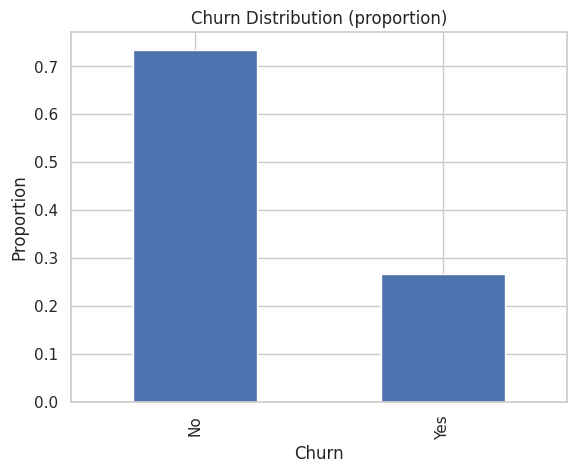

,count
Churn,
No,5174
Yes,1869


In [10]:
# Target distribution
df['Churn'].value_counts(normalize=True).plot(kind='bar', title='Churn Distribution (proportion)')
plt.ylabel('Proportion')
plt.show()

df['Churn'].value_counts()


## 4. Train/Test Split

In [11]:
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (5634, 19)  Test shape: (1409, 19)


## 5. Preprocessing Pipeline

We separate numeric and categorical columns and build a `ColumnTransformer`:
- **Numeric columns:** median imputation + `StandardScaler`
- **Categorical columns:** most-frequent imputation + `OneHotEncoder`

This preprocessing step will be embedded directly inside the final model `Pipeline`, so the exported artifact handles raw input end-to-end.


In [12]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Build Full Pipelines (Preprocessing + Model)

Each pipeline bundles preprocessing and the estimator together, so we can fit, tune, and export it as a single object.


In [13]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])


## 7. Hyperparameter Tuning with GridSearchCV

We define parameter grids for each model. Parameter names are prefixed with `classifier__` since the estimator lives inside the pipeline's `classifier` step.


In [14]:
log_reg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}


In [15]:
log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression params:", log_reg_grid.best_params_)
print("Best CV ROC-AUC:", log_reg_grid.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression params: {'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.8458978547659708


In [16]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best CV ROC-AUC: 0.847206604521346


## 8. Evaluate Both Models on the Test Set

===== Logistic Regression =====
Accuracy: 0.8006
ROC-AUC:  0.8407
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



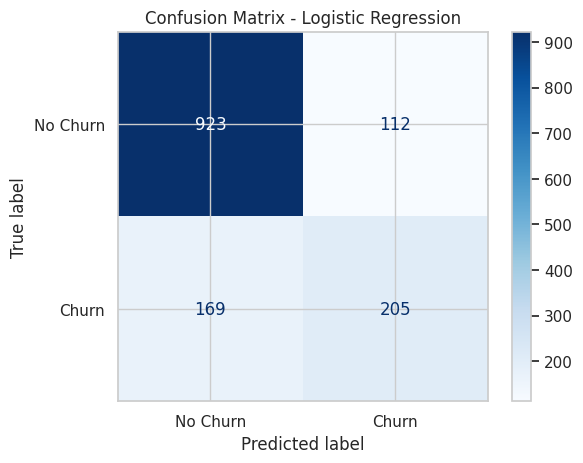

===== Random Forest =====
Accuracy: 0.8027
ROC-AUC:  0.8431
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



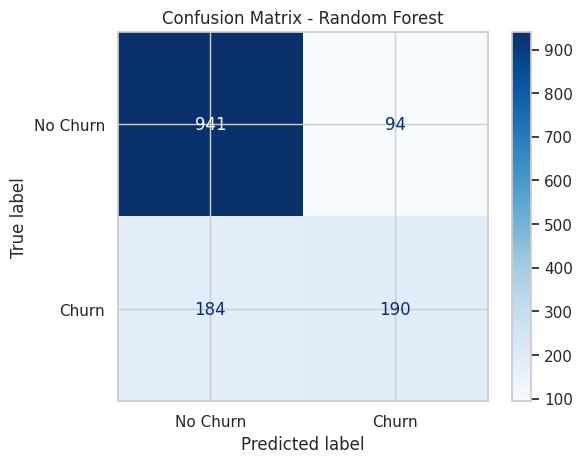

In [17]:
def evaluate_model(name, grid_search, X_test, y_test):
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"===== {name} =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return {'name': name, 'accuracy': acc, 'roc_auc': auc, 'model': best_model}

results = []
results.append(evaluate_model("Logistic Regression", log_reg_grid, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_grid, X_test, y_test))


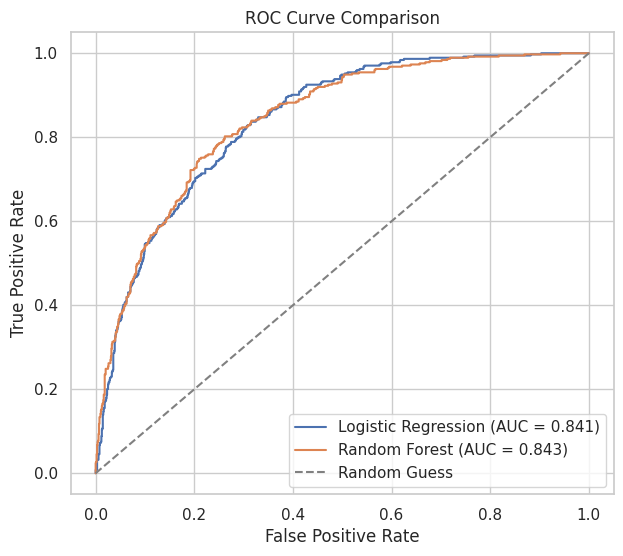

In [18]:
# ROC curves for both models on one plot
plt.figure(figsize=(7, 6))
for r in results:
    y_proba = r['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC = {r['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


## 9. Select the Best Model

In [19]:
results_df = pd.DataFrame([{'Model': r['name'], 'Accuracy': r['accuracy'], 'ROC_AUC': r['roc_auc']} for r in results])
results_df = results_df.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)
print(results_df)

best_result = max(results, key=lambda r: r['roc_auc'])
best_pipeline = best_result['model']
print(f"\nSelected best model: {best_result['name']} (ROC-AUC = {best_result['roc_auc']:.4f})")


                 Model  Accuracy   ROC_AUC
0        Random Forest  0.802697  0.843075
1  Logistic Regression  0.800568  0.840673

Selected best model: Random Forest (ROC-AUC = 0.8431)


## 10. Export the Complete Pipeline with `joblib`

The exported object includes **both preprocessing and the trained classifier**, so it can be loaded elsewhere and applied directly to raw, unprocessed input data.


In [20]:
MODEL_PATH = 'churn_prediction_pipeline.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Pipeline saved to {MODEL_PATH}")


Pipeline saved to churn_prediction_pipeline.joblib


In [21]:
# In Colab, download the saved pipeline to your local machine
try:
    from google.colab import files
    files.download(MODEL_PATH)
except ImportError:
    print("Not running in Colab - file saved locally at:", MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Verify: Load the Saved Pipeline and Predict on New Data

This simulates using the exported pipeline in production: load it fresh, feed it raw rows (same columns as the original dataset, minus `Churn`), and get predictions.


In [22]:
loaded_pipeline = joblib.load(MODEL_PATH)

# Take a few raw samples from the test set (before any manual preprocessing)
sample = X_test.head(5)

predictions = loaded_pipeline.predict(sample)
probabilities = loaded_pipeline.predict_proba(sample)[:, 1]

output = sample.copy()
output['Predicted_Churn'] = np.where(predictions == 1, 'Yes', 'No')
output['Churn_Probability'] = probabilities.round(3)
output[['Predicted_Churn', 'Churn_Probability']]


,Predicted_Churn,Churn_Probability
437,No,0.013
2280,Yes,0.670
2235,No,0.071
4460,No,0.326
3761,No,0.033


### Summary

- Built a single, reusable `Pipeline` combining imputation, scaling, one-hot encoding, and classification.
- Tuned **Logistic Regression** and **Random Forest** with `GridSearchCV` (5-fold CV, ROC-AUC scoring).
- Compared models on held-out test data using accuracy, precision/recall/F1, confusion matrix, and ROC-AUC.
- Exported the best full pipeline with `joblib` so it can be dropped into a production service and called on raw input directly — no separate preprocessing code required at inference time.
